# Norms and Distances

**Goal.** Define L0, L1, L2 norms and cosine dissimilarity.
Visualize their unit balls, compare distance behaviors, and show why feature scaling matters.


In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)


## Norm definitions

For a vector $x \in \mathbb{R}^d$:

| Norm | Formula | Interpretation |
|---|---|---|
| L0 | $\|x\|_0 = \#\{i : x_i \neq 0\}$ | Count of nonzero elements (not a true norm) |
| L1 | $\|x\|_1 = \sum_i |x_i|$ | Manhattan distance (sum of absolute values) |
| L2 | $\|x\|_2 = \sqrt{\sum_i x_i^2}$ | Euclidean distance |
| Linf | $\|x\|_\infty = \max_i |x_i|$ | Chebyshev distance (max component) |

**Key inequality:** $\|x\|_\infty \leq \|x\|_2 \leq \|x\|_1$ always holds.


## Experiment 1: Computing norms and distances


In [2]:
x = np.array([1.0, 2.0])
y = np.array([4.0, 6.0])
diff = x - y  # [-3, -4]

l0 = np.count_nonzero(diff)
l1 = np.linalg.norm(diff, ord=1)
l2 = np.linalg.norm(diff, ord=2)
linf = np.linalg.norm(diff, ord=np.inf)
cosine_dissimilarity = 1.0 - x @ y / (np.linalg.norm(x) * np.linalg.norm(y))

print(f'x = {x}, y = {y}, diff = {diff}')
print(f'L0 = {l0}')
print(f'L1 = {l1:.3f}  (|{-3}| + |{-4}| = 7)')
print(f'L2 = {l2:.3f}  (sqrt({9}+{16}) = 5)')
print(f'Linf = {linf:.3f}  (max(3,4) = 4)')
print(f'Cosine dissimilarity = {cosine_dissimilarity:.6f}')
print()

# Verify inequality: Linf <= L2 <= L1
assert linf <= l2 <= l1, 'Norm inequality violated!'
print(f'Inequality verified: {linf} <= {l2} <= {l1}')


x = [1. 2.], y = [4. 6.], diff = [-3. -4.]
L0 = 2
L1 = 7.000  (|-3| + |-4| = 7)
L2 = 5.000  (sqrt(9+16) = 5)
Linf = 4.000  (max(3,4) = 4)
Cosine dissimilarity = 0.007722

Inequality verified: 4.0 <= 5.0 <= 7.0


## Experiment 2: Unit ball visualization

The **unit ball** $\{x : \|x\|_p \leq 1\}$ reveals the geometry of each norm.
This directly connects to L1/L2 regularization: the unit ball shape determines
whether solutions are **sparse** (L1, diamond corners) or **smooth** (L2, circle).


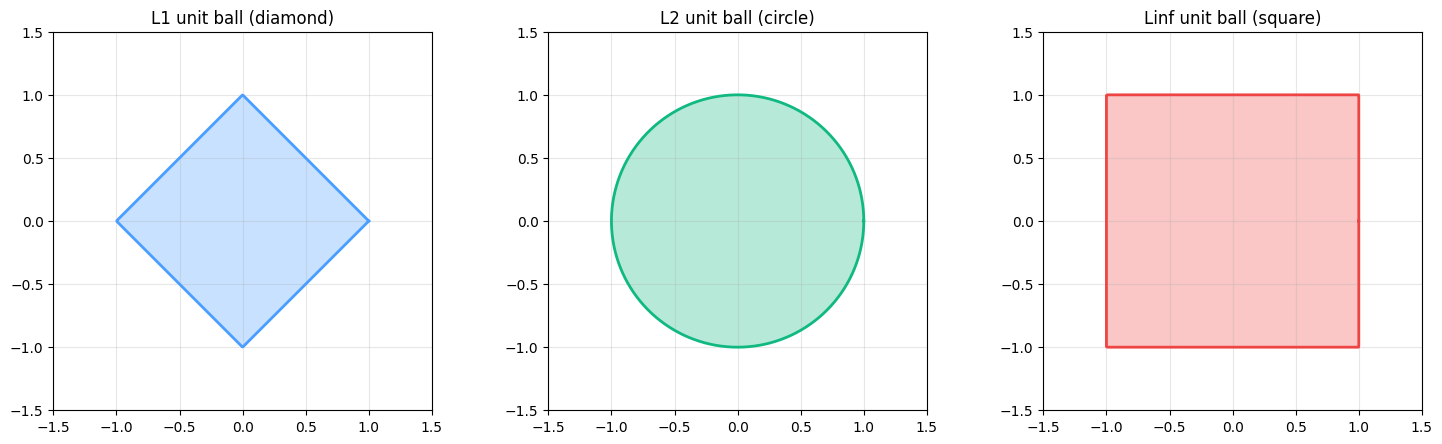

L1 diamond has sharp corners at axes -> promotes sparsity (Lasso)
L2 circle is smooth -> shrinks weights evenly (Ridge)
Linf square constrains max component


In [3]:
theta = np.linspace(0, 2 * np.pi, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# L1 unit ball (diamond)
ax = axes[0]
l1_x = np.cos(theta)
l1_y = np.sin(theta)
l1_scale = np.abs(l1_x) + np.abs(l1_y)
ax.fill(l1_x / l1_scale, l1_y / l1_scale, alpha=0.3, color='#4a9eff')
ax.plot(l1_x / l1_scale, l1_y / l1_scale, color='#4a9eff', lw=2)
ax.set_title('L1 unit ball (diamond)', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# L2 unit ball (circle)
ax = axes[1]
ax.fill(np.cos(theta), np.sin(theta), alpha=0.3, color='#10b981')
ax.plot(np.cos(theta), np.sin(theta), color='#10b981', lw=2)
ax.set_title('L2 unit ball (circle)', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# Linf unit ball (square)
ax = axes[2]
linf_x = l1_x / np.maximum(np.abs(l1_x), np.abs(l1_y))
linf_y = l1_y / np.maximum(np.abs(l1_x), np.abs(l1_y))
ax.fill(linf_x, linf_y, alpha=0.3, color='#ef4444')
ax.plot(linf_x, linf_y, color='#ef4444', lw=2)
ax.set_title('Linf unit ball (square)', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

print('L1 diamond has sharp corners at axes -> promotes sparsity (Lasso)')
print('L2 circle is smooth -> shrinks weights evenly (Ridge)')
print('Linf square constrains max component')


## Experiment 3: Cosine similarity vs Euclidean distance

**Cosine similarity** measures the angle between vectors, ignoring magnitude:

$$\text{cos\_sim}(x, y) = \frac{x^\top y}{\|x\|_2 \|y\|_2}$$

**Cosine dissimilarity** = $1 - \text{cos\_sim}(x, y)$.

Key difference: two vectors with the same direction but different magnitudes
have cosine distance = 0, but Euclidean distance > 0.


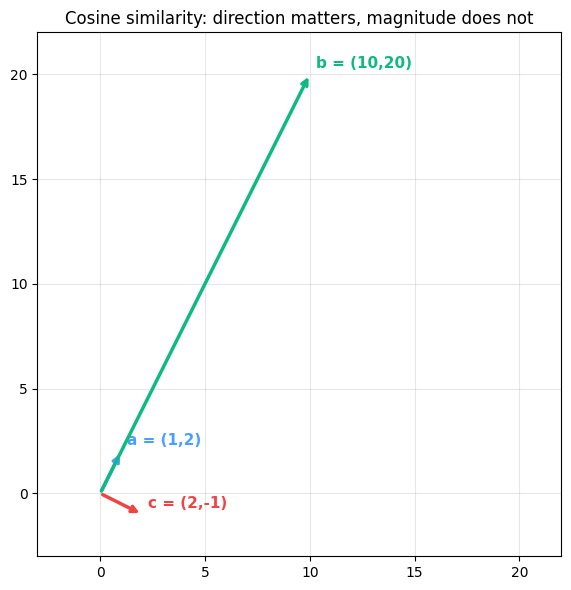

a vs b (same direction, 10x magnitude):
  cosine similarity = 1.0000  (perfect!)
  L2 distance = 20.1246  (large!)
a vs c (orthogonal):
  cosine similarity = 0.0000  (zero = orthogonal)
  L2 distance = 3.1623

Use cosine when direction matters (NLP, recommendations).
Use Euclidean when magnitude matters (physical distance, KNN).


In [4]:
# Same direction, different magnitude
a = np.array([1.0, 2.0])
b = np.array([10.0, 20.0])  # b = 10 * a

cos_sim_ab = a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
l2_dist_ab = np.linalg.norm(a - b)

# Different direction
c = np.array([2.0, -1.0])  # orthogonal to a
cos_sim_ac = a @ c / (np.linalg.norm(a) * np.linalg.norm(c))
l2_dist_ac = np.linalg.norm(a - c)

fig, ax = plt.subplots(figsize=(6, 6))
vectors = [(a, 'a = (1,2)', '#4a9eff'), (b, 'b = (10,20)', '#10b981'), (c, 'c = (2,-1)', '#ef4444')]
for v, label, color in vectors:
    ax.annotate('', xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(v[0] + 0.3, v[1] + 0.3, label, fontsize=11, color=color, fontweight='bold')

ax.set_xlim(-3, 22)
ax.set_ylim(-3, 22)
ax.set_aspect('equal')
ax.set_title('Cosine similarity: direction matters, magnitude does not')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'a vs b (same direction, 10x magnitude):')
print(f'  cosine similarity = {cos_sim_ab:.4f}  (perfect!)')
print(f'  L2 distance = {l2_dist_ab:.4f}  (large!)')
print(f'a vs c (orthogonal):')
print(f'  cosine similarity = {cos_sim_ac:.4f}  (zero = orthogonal)')
print(f'  L2 distance = {l2_dist_ac:.4f}')
print()
print('Use cosine when direction matters (NLP, recommendations).')
print('Use Euclidean when magnitude matters (physical distance, KNN).')


## Experiment 4: Feature scaling changes nearest neighbor

When features have different scales, the larger-scale feature **dominates** the distance.
Normalizing by feature scale fixes this.


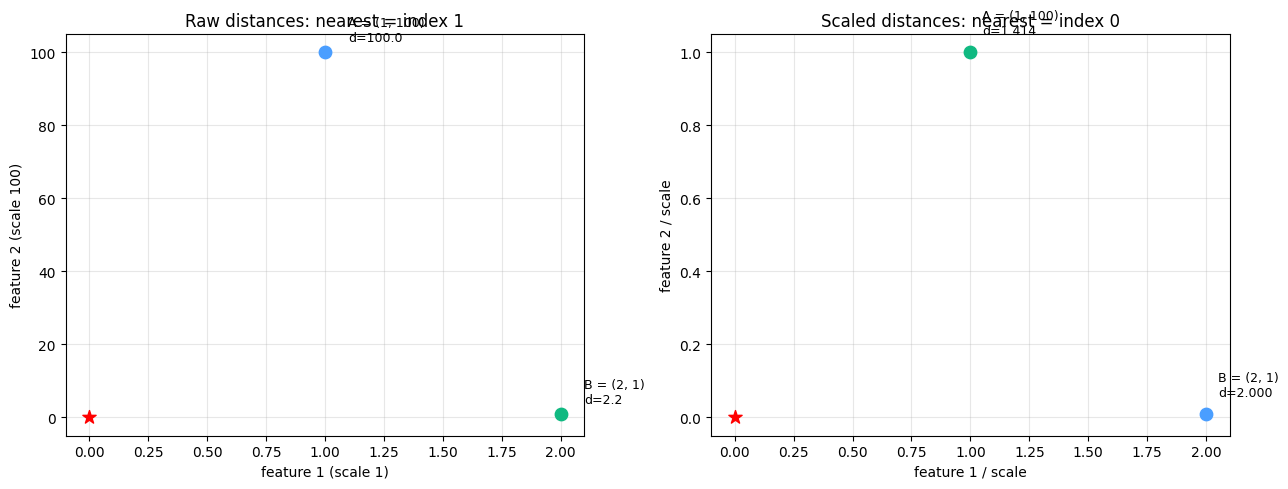

Raw: nearest = B = (2, 1) (dominated by feature 2)
Scaled: nearest = A = (1, 100) (balanced)
Feature scaling changes the nearest neighbor! Always normalize before KNN.


In [5]:
query = np.array([0.0, 0.0])
points = np.array([[1.0, 100.0], [2.0, 1.0]])
labels = ['A = (1, 100)', 'B = (2, 1)']

# Raw distances
raw_dists = np.linalg.norm(points - query, axis=1)
raw_nn = np.argmin(raw_dists)

# Scaled distances
feature_scales = np.array([1.0, 100.0])
scaled_dists = np.linalg.norm(points / feature_scales - query, axis=1)
scaled_nn = np.argmin(scaled_dists)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw
ax = axes[0]
ax.scatter(*query, s=100, c='red', zorder=5, marker='*', label='Query (0,0)')
for i, (pt, lbl) in enumerate(zip(points, labels)):
    color = '#10b981' if i == raw_nn else '#4a9eff'
    ax.scatter(*pt, s=80, c=color, zorder=5)
    ax.text(pt[0]+0.1, pt[1]+3, f'{lbl}\nd={raw_dists[i]:.1f}', fontsize=9)
ax.set_title(f'Raw distances: nearest = index {raw_nn}')
ax.set_xlabel('feature 1 (scale 1)')
ax.set_ylabel('feature 2 (scale 100)')
ax.grid(True, alpha=0.3)

# Right: scaled
ax = axes[1]
pts_scaled = points / feature_scales
ax.scatter(0, 0, s=100, c='red', zorder=5, marker='*', label='Query (0,0)')
for i, lbl in enumerate(labels):
    color = '#10b981' if i == scaled_nn else '#4a9eff'
    ax.scatter(*pts_scaled[i], s=80, c=color, zorder=5)
    ax.text(pts_scaled[i][0]+0.05, pts_scaled[i][1]+0.05, f'{lbl}\nd={scaled_dists[i]:.3f}', fontsize=9)
ax.set_title(f'Scaled distances: nearest = index {scaled_nn}')
ax.set_xlabel('feature 1 / scale')
ax.set_ylabel('feature 2 / scale')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Raw: nearest = {labels[raw_nn]} (dominated by feature 2)')
print(f'Scaled: nearest = {labels[scaled_nn]} (balanced)')
assert raw_nn != scaled_nn, 'Scaling should change the nearest neighbor'
print('Feature scaling changes the nearest neighbor! Always normalize before KNN.')


## Result

1. **Norm inequality**: $\|x\|_\infty \leq \|x\|_2 \leq \|x\|_1$ -- L1 is always >= L2.
2. **Unit ball shape** determines regularization behavior: L1 diamond -> sparsity (Lasso), L2 circle -> shrinkage (Ridge).
3. **Cosine similarity** measures direction only (ignores magnitude) -- use for NLP/recommendations.
4. **Feature scaling** is critical: unscaled features let high-magnitude features dominate distances.


## CONNECTIONS

- [KNN](../../topics/07_knn/README.md): distance metric choice directly affects classification
- [K-Means / DBSCAN](../../topics/): clustering relies on distance definitions
- [SVM](../../topics/09_svm/README.md): margin = distance from hyperplane (L2)
- [Linear Regression](../../topics/01_linear_regression/README.md): L1 reg (Lasso) vs L2 reg (Ridge)
- [vectors_and_matrices.md](./vectors_and_matrices.md): norm definitions, inner products
